# Digit classification

Handwritten digits from `data/digits.csv` (64 features per sample, labels 0–9).

In [6]:
from pathlib import Path

import pandas as pd

data_path = r"/content/drive/MyDrive/589FinalProject/589-Final-Project/data/digits.csv"
df = pd.read_csv(data_path)

X = df.drop(columns=["label"])
y = df["label"]

print(X.shape, y.shape)
df.head()

(1797, 64) (1797,)


,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,pixel_9,...,pixel_55,pixel_56,pixel_57,pixel_58,pixel_59,pixel_60,pixel_61,pixel_62,pixel_63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


### Exploratory analysis (report figures)

Bar chart of class frequencies and a $10 \times 10$ grid of example $8 \times 8$ digit images. PNGs are written to `589_finalsub/` for the LaTeX report (same folder as `main.tex`).

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


def _report_fig_dir() -> Path:
    """Folder next to main.tex (works from Colab or local repo checkout)."""
    cwd = Path.cwd().resolve()
    for base in (cwd, cwd.parent, cwd / "589-Final-Project"):
        d = base / "589_finalsub"
        if d.is_dir():
            return d
    colab = Path(
        "/content/drive/MyDrive/589FinalProject/589-Final-Project/589_finalsub"
    )
    if colab.is_dir():
        return colab
    d = cwd / "589_finalsub"
    d.mkdir(parents=True, exist_ok=True)
    return d


OUT = _report_fig_dir()

# --- Class distribution ---
fig, ax = plt.subplots(figsize=(7.5, 4))
counts = y.value_counts().sort_index()
ax.bar(counts.index.astype(str), counts.values, color="steelblue", edgecolor="black", linewidth=0.6)
ax.set_xlabel("Digit label")
ax.set_ylabel("Number of samples")
ax.set_title("Digits dataset: class frequencies (n = %d)" % len(y))
ax.grid(True, axis="y", alpha=0.35)
plt.tight_layout()
p_bar = OUT / "digits_class_distribution.png"
fig.savefig(p_bar, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p_bar.resolve())

# --- Sample digit grid: 10 columns × 10 rows, one row per digit label ---
rng = np.random.default_rng(42)
fig, axes = plt.subplots(10, 10, figsize=(10, 10))
for digit in range(10):
    idx_all = np.where(y.to_numpy() == digit)[0]
    pick = rng.choice(idx_all, size=10, replace=False)
    for j in range(10):
        ax = axes[digit, j]
        img = X.iloc[pick[j]].to_numpy(dtype=float).reshape(8, 8)
        ax.imshow(img, cmap="gray_r", interpolation="nearest")
        ax.set_xticks([])
        ax.set_yticks([])
        if j == 0:
            ax.set_ylabel(str(digit), rotation=0, labelpad=10, fontsize=11, fontweight="bold")
fig.suptitle(r"Random examples per digit (8$\times$8 pixels)", y=1.002, fontsize=13)
plt.tight_layout()
p_grid = OUT / "digits_sample_grid.png"
fig.savefig(p_grid, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", p_grid.resolve())


## Methods (digits dataset)

This notebook is structured for the **final project checklist**: stratified **10-fold CV**; **mean accuracy** and **mean weighted F1** per configuration; **hyperparameter tables** (≥6 settings for each tuned algorithm); **figures** for interpretation; and a **discussion template** at the end.

| Model | Implementation | Why here |
|-------|----------------|----------|
| **k-NN** | Course `algo/knn.py` | Strong baseline on normalized numeric pixels; tune **`k`**. |
| **Random Forest** | Course `algo/random_forest.py` | Bagging + tree votes; tune **`ntree`**. *On digits, each tree can grow very large in pure Python; this notebook uses a **depth cap** (`RF_TREE_MAX_DEPTH`) so CV finishes in reasonable time — mention this in the report.* |
| **Gaussian Naive Bayes** | `sklearn.naive_bayes.GaussianNB` | **Baseline** generative classifier for continuous features (Gaussian likelihood per class). Course `algo/naive_bayes.py` is **multinomial / text** — not used for digits. Report **one CV row** (default hyperparameters). |
| **Gradient Boosting** | `sklearn.ensemble.GradientBoostingClassifier` | Sequential ensemble; tune **`n_estimators`** ∈ {10,25,50,100} × **`learning_rate`** ∈ {0.01,0.1,0.5} (**12** settings). |
| **Custom ensemble** | Majority vote | Combines **best k-NN**, **best RF**, and **Gaussian NB** each fold — diversity of biases (instance-based, bagged trees, generative). |

**Convention:** Use the same `StratifiedKFold(random_state=42)` splits via the helper functions so metrics are comparable.

**Run cells in order** — the ensemble cell requires `table_knn` and `table_rf` from earlier.

In [7]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import StratifiedKFold

ALGO_DIR = Path("/content/drive/MyDrive/589FinalProject/589-Final-Project/algo")
if not ALGO_DIR.is_dir():
    raise FileNotFoundError(
        f"Expected algo/ at {ALGO_DIR} — open/run the notebook with the project root (589-Final-Project) as the working directory."
    )
sys.path.insert(0, str(ALGO_DIR))

from knn import KNN, normalize
from random_forest import RandomForest

RANDOM_STATE = 42
N_SPLITS = 10
# Custom trees split on every distinct pixel value; unlimited depth makes RF on digits take hours in pure Python.
RF_TREE_MAX_DEPTH = 12

def evaluate_knn_stratified_cv(X_df, y_series, k, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    X_np = X_df.to_numpy(dtype=float)
    y_np = y_series.to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    for train_idx, val_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np[train_idx], X_np[val_idx]
        y_tr, y_va = y_np[train_idx], y_np[val_idx]
        X_tr_n, X_va_n = normalize(X_tr, X_va)
        knn = KNN(k=k)
        knn.fit(X_tr_n, y_tr)
        pred = knn.predict(X_va_n)
        accs.append(accuracy_score(y_va, pred))
        f1s.append(f1_score(y_va, pred, average="weighted", zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))


def evaluate_rf_stratified_cv(
    X_df,
    y_series,
    ntree,
    min_size_for_split=2,
    max_depth=RF_TREE_MAX_DEPTH,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
    verbose=True,
):
    y_np = y_series.to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_df, y_np)):
        if verbose:
            print(f"  RF ntree={ntree}  fold {fold_idx + 1}/{n_splits} ...", flush=True)
        np.random.seed(random_state + fold_idx * 97)
        X_tr, X_va = X_df.iloc[train_idx], X_df.iloc[val_idx]
        y_tr, y_va = y_np[train_idx], y_np[val_idx]
        rf = RandomForest(ntree=ntree, min_size_for_split=min_size_for_split, max_depth=max_depth)
        rf.fit(X_tr, y_tr)
        pred = rf.predict(X_va)
        accs.append(accuracy_score(y_va, pred))
        f1s.append(f1_score(y_va, pred, average="weighted", zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))

In [8]:
# k-NN: six hyperparameter settings (k)
k_grid = [1, 3, 5, 7, 9, 11]
knn_rows = []
for k in k_grid:
    acc, f1 = evaluate_knn_stratified_cv(X, y, k)
    knn_rows.append(
        {
            "algorithm": "k-NN",
            "hyperparameter": f"k={k}",
            "mean_accuracy": acc,
            "mean_f1_weighted": f1,
        }
    )

table_knn = pd.DataFrame(knn_rows)
display(table_knn)

best_knn_row = table_knn.loc[table_knn["mean_f1_weighted"].idxmax()]
print("Best k-NN (by mean weighted F1 across folds):")
display(best_knn_row.to_frame().T)

,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,k-NN,k=1,0.973839,0.973777
1,k-NN,k=3,0.976620,0.976607
2,k-NN,k=5,0.978845,0.978727
3,k-NN,k=7,0.974395,0.974367
4,k-NN,k=9,0.976065,0.976042
5,k-NN,k=11,0.969950,0.969875


Best k-NN (by mean weighted F1 across folds):


,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
2,k-NN,k=5,0.978845,0.978727


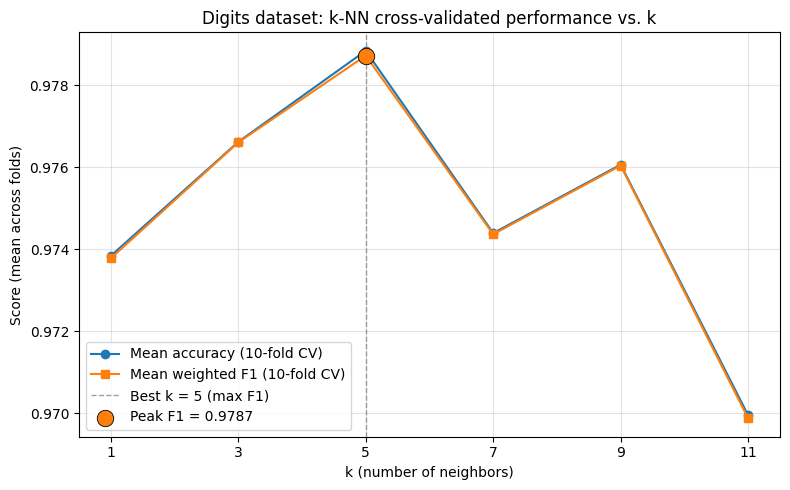

In [9]:
import matplotlib.pyplot as plt

# Uses `table_knn` from the cell above
ks = [int(s.split("=")[1]) for s in table_knn["hyperparameter"]]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, table_knn["mean_accuracy"], marker="o", label="Mean accuracy (10-fold CV)")
ax.plot(ks, table_knn["mean_f1_weighted"], marker="s", label="Mean weighted F1 (10-fold CV)")

best_i = int(table_knn["mean_f1_weighted"].idxmax())
best_k = ks[best_i]
best_f1 = float(table_knn["mean_f1_weighted"].iloc[best_i])
ax.axvline(best_k, color="gray", linestyle="--", alpha=0.75, linewidth=1, label=f"Best k = {best_k} (max F1)")
ax.scatter([best_k], [best_f1], s=140, zorder=5, color="C1", edgecolors="black", linewidths=0.6, label=f"Peak F1 = {best_f1:.4f}")

ax.set_xlabel("k (number of neighbors)")
ax.set_ylabel("Score (mean across folds)")
ax.set_title("Digits dataset: k-NN cross-validated performance vs. k")
ax.set_xticks(ks)
ax.legend(loc="lower left")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

In [10]:
# Random Forest: six hyperparameter settings (ntree)
# (150 trees + unbounded depth was taking ~1h+; use cap RF_TREE_MAX_DEPTH in helper, max 100 trees here.)
ntree_grid = [10, 25, 50, 75, 100, 125]
rf_rows = []
for ntree in ntree_grid:
    print(f"=== Random Forest: ntree={ntree} (10 folds) ===", flush=True)
    acc, f1 = evaluate_rf_stratified_cv(X, y, ntree)
    rf_rows.append(
        {
            "algorithm": "Random Forest",
            "hyperparameter": f"ntree={ntree}",
            "mean_accuracy": acc,
            "mean_f1_weighted": f1,
        }
    )

table_rf = pd.DataFrame(rf_rows)
display(table_rf)

best_rf_row = table_rf.loc[table_rf["mean_f1_weighted"].idxmax()]
print("Best Random Forest (by mean weighted F1 across folds):")
display(best_rf_row.to_frame().T)

# Combined table: 12 hyperparameter trials (>= 6 required)
hyperparam_search_results = pd.concat([table_knn, table_rf], ignore_index=True)
print("All hyperparameter trials:")
display(hyperparam_search_results)

=== Random Forest: ntree=10 (10 folds) ===
  RF ntree=10  fold 1/10 ...
  RF ntree=10  fold 2/10 ...
  RF ntree=10  fold 3/10 ...
  RF ntree=10  fold 4/10 ...
  RF ntree=10  fold 5/10 ...
  RF ntree=10  fold 6/10 ...
  RF ntree=10  fold 7/10 ...
  RF ntree=10  fold 8/10 ...
  RF ntree=10  fold 9/10 ...
  RF ntree=10  fold 10/10 ...
=== Random Forest: ntree=25 (10 folds) ===
  RF ntree=25  fold 1/10 ...
  RF ntree=25  fold 2/10 ...
  RF ntree=25  fold 3/10 ...
  RF ntree=25  fold 4/10 ...
  RF ntree=25  fold 5/10 ...
  RF ntree=25  fold 6/10 ...
  RF ntree=25  fold 7/10 ...
  RF ntree=25  fold 8/10 ...
  RF ntree=25  fold 9/10 ...
  RF ntree=25  fold 10/10 ...
=== Random Forest: ntree=50 (10 folds) ===
  RF ntree=50  fold 1/10 ...
  RF ntree=50  fold 2/10 ...
  RF ntree=50  fold 3/10 ...
  RF ntree=50  fold 4/10 ...
  RF ntree=50  fold 5/10 ...
  RF ntree=50  fold 6/10 ...
  RF ntree=50  fold 7/10 ...
  RF ntree=50  fold 8/10 ...
  RF ntree=50  fold 9/10 ...
  RF ntree=50  fold 10/10 ..

,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,Random Forest,ntree=10,0.700053,0.690964
1,Random Forest,ntree=25,0.819137,0.811515
2,Random Forest,ntree=50,0.854745,0.850452
3,Random Forest,ntree=75,0.868669,0.863932
4,Random Forest,ntree=100,0.880906,0.875960
5,Random Forest,ntree=125,0.888700,0.885011


Best Random Forest (by mean weighted F1 across folds):


,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
5,Random Forest,ntree=125,0.8887,0.885011


All hyperparameter trials:


,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,k-NN,k=1,0.973839,0.973777
1,k-NN,k=3,0.976620,0.976607
2,k-NN,k=5,0.978845,0.978727
3,k-NN,k=7,0.974395,0.974367
4,k-NN,k=9,0.976065,0.976042
5,k-NN,k=11,0.969950,0.969875
6,Random Forest,ntree=10,0.700053,0.690964
7,Random Forest,ntree=25,0.819137,0.811515
8,Random Forest,ntree=50,0.854745,0.850452
9,Random Forest,ntree=75,0.868669,0.863932


### Part B — Gaussian NB, Gradient Boosting, majority-vote ensemble

Run after Part A so `table_knn` and `table_rf` exist. **Gaussian NB** adds a fast probabilistic baseline. **Gradient boosting** explores **12** hyperparameter combinations (≥6 required). The **ensemble** uses **majority vote** among best **k-NN**, best **RF**, and **Gaussian NB** on each fold.

In [11]:
from collections import Counter

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB


def evaluate_gaussian_nb_cv(X_df, y_series, n_splits=N_SPLITS, random_state=RANDOM_STATE):
    X_np = X_df.to_numpy(dtype=float)
    y_np = y_series.to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    for train_idx, val_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np[train_idx], X_np[val_idx]
        y_tr, y_va = y_np[train_idx], y_np[val_idx]
        clf = GaussianNB()
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_va)
        accs.append(accuracy_score(y_va, pred))
        f1s.append(f1_score(y_va, pred, average="weighted", zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))


def evaluate_gradient_boosting_cv(
    X_df,
    y_series,
    n_estimators,
    learning_rate,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
):
    X_np = X_df.to_numpy(dtype=float)
    y_np = y_series.to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    for train_idx, val_idx in skf.split(X_np, y_np):
        X_tr, X_va = X_np[train_idx], X_np[val_idx]
        y_tr, y_va = y_np[train_idx], y_np[val_idx]
        clf = GradientBoostingClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            random_state=random_state,
        )
        clf.fit(X_tr, y_tr)
        pred = clf.predict(X_va)
        accs.append(accuracy_score(y_va, pred))
        f1s.append(f1_score(y_va, pred, average="weighted", zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))


def _majority_vote_rows(preds: np.ndarray) -> np.ndarray:
    out = np.empty(preds.shape[0], dtype=int)
    for i in range(preds.shape[0]):
        row = preds[i].astype(int, copy=False)
        out[i] = Counter(row).most_common(1)[0][0]
    return out


def evaluate_majority_vote_ensemble_cv(
    X_df,
    y_series,
    k: int,
    ntree: int,
    n_splits=N_SPLITS,
    random_state=RANDOM_STATE,
):
    """Best k-NN + best RF + GaussianNB — majority vote per validation fold."""
    X_np = X_df.to_numpy(dtype=float)
    y_np = y_series.to_numpy()
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    accs, f1s = [], []
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_np, y_np)):
        X_tr_df, X_va_df = X_df.iloc[train_idx], X_df.iloc[val_idx]
        y_tr, y_va = y_np[train_idx], y_np[val_idx]
        X_tr_np, X_va_np = X_tr_df.to_numpy(dtype=float), X_va_df.to_numpy(dtype=float)
        X_tr_n, X_va_n = normalize(X_tr_np, X_va_np)
        knn = KNN(k=k)
        knn.fit(X_tr_n, y_tr)
        p_knn = knn.predict(X_va_n)
        np.random.seed(random_state + fold_idx * 97)
        rf = RandomForest(
            ntree=ntree, min_size_for_split=2, max_depth=RF_TREE_MAX_DEPTH
        )
        rf.fit(X_tr_df, y_tr)
        p_rf = rf.predict(X_va_df)
        gnb = GaussianNB()
        gnb.fit(X_tr_np, y_tr)
        p_nb = gnb.predict(X_va_np)
        preds = np.column_stack([p_knn, p_rf, p_nb])
        pred = _majority_vote_rows(preds)
        accs.append(accuracy_score(y_va, pred))
        f1s.append(f1_score(y_va, pred, average="weighted", zero_division=0))
    return float(np.mean(accs)), float(np.mean(f1s))


def parse_best_k(table_knn: pd.DataFrame) -> int:
    row = table_knn.loc[table_knn["mean_f1_weighted"].idxmax()]
    return int(str(row["hyperparameter"]).split("=")[1])


def parse_best_ntree(table_rf: pd.DataFrame) -> int:
    row = table_rf.loc[table_rf["mean_f1_weighted"].idxmax()]
    return int(str(row["hyperparameter"]).split("=")[1])

In [12]:
# Gaussian Naive Bayes — baseline (sklearn defaults; no discrete tuning grid)
acc_gnb, f1_gnb = evaluate_gaussian_nb_cv(X, y)
table_gnb = pd.DataFrame(
    [
        {
            "algorithm": "Gaussian NB",
            "hyperparameter": "GaussianNB() defaults",
            "mean_accuracy": acc_gnb,
            "mean_f1_weighted": f1_gnb,
        }
    ]
)
display(table_gnb)
print(f"Gaussian NB — mean accuracy: {acc_gnb:.6f}, mean weighted F1: {f1_gnb:.6f}")

,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,Gaussian NB,GaussianNB() defaults,0.842511,0.843892


Gaussian NB — mean accuracy: 0.842511, mean weighted F1: 0.843892


In [13]:
# Gradient Boosting: 12 hyperparameter settings (n_estimators × learning_rate)
n_estimators_grid = [10, 25, 50, 100]
learning_rate_grid = [0.01, 0.1, 0.5]

gb_rows = []
for n_est in n_estimators_grid:
    for lr in learning_rate_grid:
        acc, f1 = evaluate_gradient_boosting_cv(X, y, n_est, lr)
        gb_rows.append(
            {
                "algorithm": "Gradient Boosting",
                "hyperparameter": f"n_estimators={n_est}, learning_rate={lr}",
                "n_estimators": n_est,
                "learning_rate": lr,
                "mean_accuracy": acc,
                "mean_f1_weighted": f1,
            }
        )

table_gb = pd.DataFrame(gb_rows)
display(table_gb.sort_values(["learning_rate", "n_estimators"]).reset_index(drop=True))

best_gb_row = table_gb.loc[table_gb["mean_f1_weighted"].idxmax()]
print("Best Gradient Boosting (by mean weighted F1):")
display(best_gb_row.to_frame().T)

,algorithm,hyperparameter,n_estimators,learning_rate,mean_accuracy,mean_f1_weighted
0,Gradient Boosting,"n_estimators=10, learning_rate=0.01",10,0.01,0.844199,0.842814
1,Gradient Boosting,"n_estimators=25, learning_rate=0.01",25,0.01,0.859212,0.858642
2,Gradient Boosting,"n_estimators=50, learning_rate=0.01",50,0.01,0.875906,0.875702
3,Gradient Boosting,"n_estimators=100, learning_rate=0.01",100,0.01,0.899817,0.899958
4,Gradient Boosting,"n_estimators=10, learning_rate=0.1",10,0.10,0.898709,0.898703
5,Gradient Boosting,"n_estimators=25, learning_rate=0.1",25,0.10,0.941558,0.941581
6,Gradient Boosting,"n_estimators=50, learning_rate=0.1",50,0.10,0.955481,0.955290
7,Gradient Boosting,"n_estimators=100, learning_rate=0.1",100,0.10,0.965500,0.965543
8,Gradient Boosting,"n_estimators=10, learning_rate=0.5",10,0.50,0.942688,0.942467
9,Gradient Boosting,"n_estimators=25, learning_rate=0.5",25,0.50,0.963830,0.963720


Best Gradient Boosting (by mean weighted F1):


,algorithm,hyperparameter,n_estimators,learning_rate,mean_accuracy,mean_f1_weighted
11,Gradient Boosting,"n_estimators=100, learning_rate=0.5",100,0.5,0.97496,0.974836


In [14]:
# Majority vote: best k-NN + best RF + Gaussian NB (same CV folds as helpers above)
best_k_star = parse_best_k(table_knn)
best_ntree_star = parse_best_ntree(table_rf)

acc_ens, f1_ens = evaluate_majority_vote_ensemble_cv(X, y, best_k_star, best_ntree_star)
table_ensemble = pd.DataFrame(
    [
        {
            "algorithm": "Ensemble (majority vote)",
            "hyperparameter": f"knn_k={best_k_star}, rf_ntree={best_ntree_star}, +GaussianNB",
            "mean_accuracy": acc_ens,
            "mean_f1_weighted": f1_ens,
        }
    ]
)
display(table_ensemble)
print(
    f"Using best k={best_k_star} (k-NN), ntree={best_ntree_star} (RF), plus GaussianNB.\n"
    f"Ensemble — mean accuracy: {acc_ens:.6f}, mean weighted F1: {f1_ens:.6f}"
)

hyperparam_search_all = pd.concat(
    [hyperparam_search_results, table_gnb, table_gb[["algorithm", "hyperparameter", "mean_accuracy", "mean_f1_weighted"]], table_ensemble],
    ignore_index=True,
)
print("Combined hyperparameter / model summary table:")
display(hyperparam_search_all)

,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,Ensemble (majority vote),"knn_k=5, rf_ntree=125, +GaussianNB",0.961586,0.961554


Using best k=5 (k-NN), ntree=125 (RF), plus GaussianNB.
Ensemble — mean accuracy: 0.961586, mean weighted F1: 0.961554
Combined hyperparameter / model summary table:


,algorithm,hyperparameter,mean_accuracy,mean_f1_weighted
0,k-NN,k=1,0.973839,0.973777
1,k-NN,k=3,0.976620,0.976607
2,k-NN,k=5,0.978845,0.978727
3,k-NN,k=7,0.974395,0.974367
4,k-NN,k=9,0.976065,0.976042
5,k-NN,k=11,0.969950,0.969875
6,Random Forest,ntree=10,0.700053,0.690964
7,Random Forest,ntree=25,0.819137,0.811515
8,Random Forest,ntree=50,0.854745,0.850452
9,Random Forest,ntree=75,0.868669,0.863932


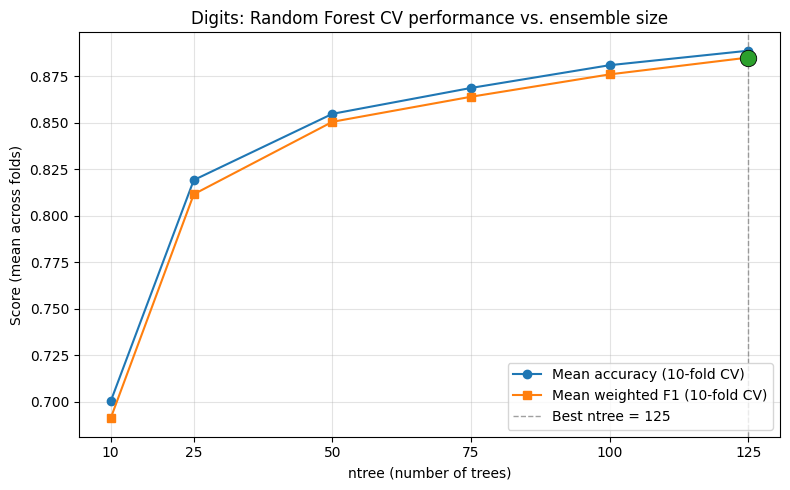

In [15]:
# Random Forest: mean CV score vs. ntree (for report / project graph)
import matplotlib.pyplot as plt

ntrees = [int(s.split("=")[1]) for s in table_rf["hyperparameter"]]
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ntrees, table_rf["mean_accuracy"], marker="o", label="Mean accuracy (10-fold CV)")
ax.plot(ntrees, table_rf["mean_f1_weighted"], marker="s", label="Mean weighted F1 (10-fold CV)")
bi = int(table_rf["mean_f1_weighted"].idxmax())
best_nt = ntrees[bi]
best_f1_rf = float(table_rf["mean_f1_weighted"].iloc[bi])
ax.axvline(best_nt, color="gray", linestyle="--", alpha=0.75, linewidth=1, label=f"Best ntree = {best_nt}")
ax.scatter([best_nt], [best_f1_rf], s=140, zorder=5, color="C2", edgecolors="black", linewidths=0.6)
ax.set_xlabel("ntree (number of trees)")
ax.set_ylabel("Score (mean across folds)")
ax.set_title("Digits: Random Forest CV performance vs. ensemble size")
ax.set_xticks(ntrees)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

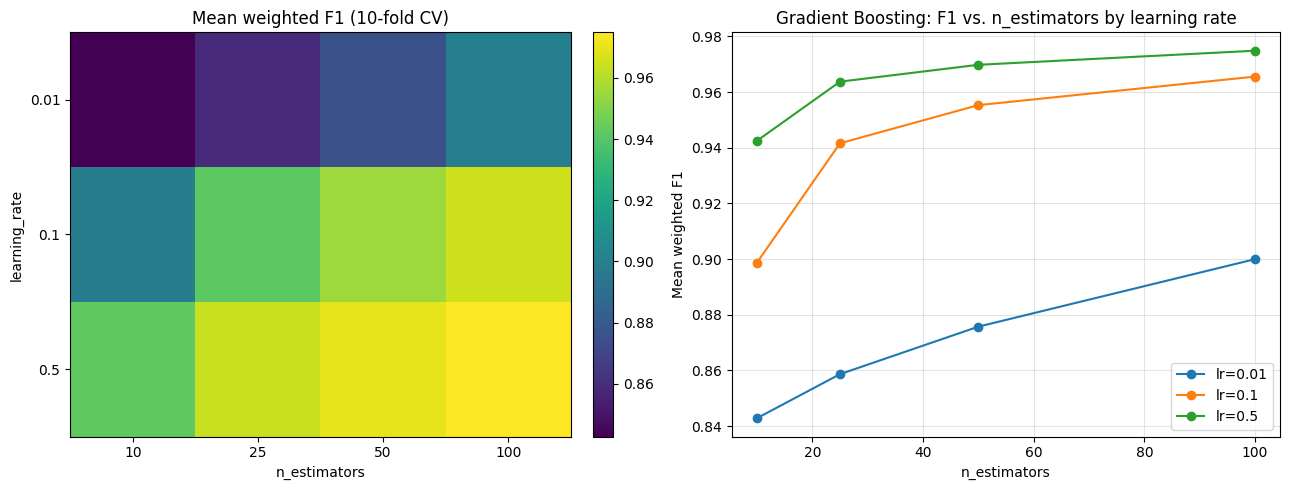

In [16]:
# Gradient Boosting: heatmap (F1) + lines (F1 vs n_estimators per learning_rate)
pivot_f1 = table_gb.pivot(index="learning_rate", columns="n_estimators", values="mean_f1_weighted")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

im = axes[0].imshow(pivot_f1.values, aspect="auto", cmap="viridis")
axes[0].set_xticks(range(len(pivot_f1.columns)))
axes[0].set_xticklabels(pivot_f1.columns)
axes[0].set_yticks(range(len(pivot_f1.index)))
axes[0].set_yticklabels(pivot_f1.index)
axes[0].set_xlabel("n_estimators")
axes[0].set_ylabel("learning_rate")
axes[0].set_title("Mean weighted F1 (10-fold CV)")
plt.colorbar(im, ax=axes[0], fraction=0.046, pad=0.04)

for lr in sorted(table_gb["learning_rate"].unique()):
    sub = table_gb[table_gb["learning_rate"] == lr].sort_values("n_estimators")
    axes[1].plot(
        sub["n_estimators"],
        sub["mean_f1_weighted"],
        marker="o",
        label=f"lr={lr}",
    )
axes[1].set_xlabel("n_estimators")
axes[1].set_ylabel("Mean weighted F1")
axes[1].set_title("Gradient Boosting: F1 vs. n_estimators by learning rate")
axes[1].legend()
axes[1].grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

,model,mean_accuracy,mean_f1_weighted
0,k-NN (best k),0.978845,0.978727
1,Random Forest (best ntree),0.888700,0.885011
2,Gaussian NB,0.842511,0.843892
3,Gradient Boosting (best grid),0.974960,0.974836
4,Majority vote ensemble,0.961586,0.961554


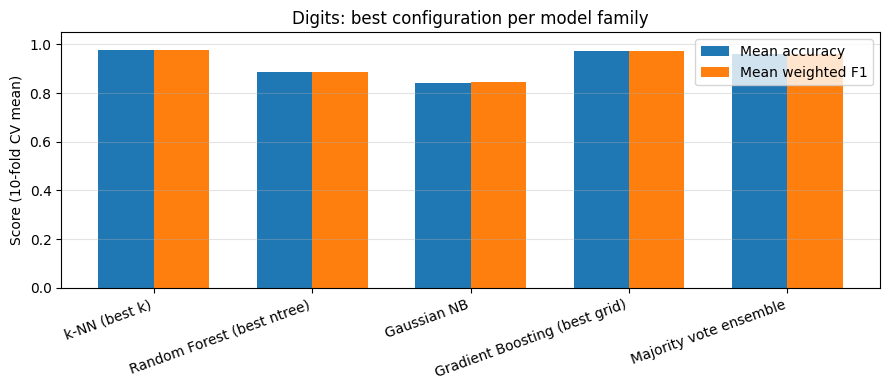

In [17]:
# Best-of-each-model comparison (digits)
summary_rows = [
    {
        "model": "k-NN (best k)",
        "mean_accuracy": float(table_knn["mean_accuracy"].max()),
        "mean_f1_weighted": float(table_knn["mean_f1_weighted"].max()),
    },
    {
        "model": "Random Forest (best ntree)",
        "mean_accuracy": float(table_rf["mean_accuracy"].max()),
        "mean_f1_weighted": float(table_rf["mean_f1_weighted"].max()),
    },
    {
        "model": "Gaussian NB",
        "mean_accuracy": acc_gnb,
        "mean_f1_weighted": f1_gnb,
    },
    {
        "model": "Gradient Boosting (best grid)",
        "mean_accuracy": float(table_gb["mean_accuracy"].max()),
        "mean_f1_weighted": float(table_gb["mean_f1_weighted"].max()),
    },
    {
        "model": "Majority vote ensemble",
        "mean_accuracy": acc_ens,
        "mean_f1_weighted": f1_ens,
    },
]
summary_compare = pd.DataFrame(summary_rows)
display(summary_compare)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(summary_compare))
w = 0.35
ax.bar(x - w / 2, summary_compare["mean_accuracy"], w, label="Mean accuracy")
ax.bar(x + w / 2, summary_compare["mean_f1_weighted"], w, label="Mean weighted F1")
ax.set_xticks(x)
ax.set_xticklabels(summary_compare["model"], rotation=20, ha="right")
ax.set_ylabel("Score (10-fold CV mean)")
ax.set_title("Digits: best configuration per model family")
ax.legend()
ax.grid(True, axis="y", alpha=0.35)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

In [18]:
# Save all tables and run metadata to results/digits/ (CSV, JSON, pickle)
import json
import pickle
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd

RESULTS_DIR = Path("/content/drive/MyDrive/589FinalProject/589-Final-Project/results") / "digits"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def _to_jsonable(obj):
    if obj is None or isinstance(obj, (str, bool)):
        return obj
    if isinstance(obj, (np.floating, float)):
        return float(obj)
    if isinstance(obj, (np.integer, int)):
        return int(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, dict):
        return {str(k): _to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_to_jsonable(x) for x in obj]
    return str(obj)


def save_csv(name: str, df: pd.DataFrame) -> Path:
    path = RESULTS_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path.resolve())
    return path


# --- Tables ---
save_csv("table_knn", table_knn)
save_csv("table_random_forest", table_rf)
save_csv("hyperparam_knn_rf_only", hyperparam_search_results)
save_csv("table_gaussian_nb", table_gnb)
save_csv("table_gradient_boosting", table_gb)
save_csv("table_ensemble_majority_vote", table_ensemble)
save_csv("hyperparam_search_all_models", hyperparam_search_all)
save_csv("summary_best_per_model_family", summary_compare)

best_configs = pd.DataFrame(
    [
        {"name": "best_knn", **_to_jsonable(best_knn_row.to_dict())},
        {"name": "best_random_forest", **_to_jsonable(best_rf_row.to_dict())},
        {"name": "best_gradient_boosting", **_to_jsonable(best_gb_row.to_dict())},
    ]
)
save_csv("best_single_rows", best_configs)

# --- Metadata JSON ---
meta = {
    "dataset_csv": str(Path("data/digits.csv")),
    "n_samples": int(len(y)),
    "n_features": int(X.shape[1]),
    "cv_splits": N_SPLITS,
    "random_state": int(RANDOM_STATE),
    "random_forest_max_depth_cap": int(RF_TREE_MAX_DEPTH),
    "best_k_knn": int(parse_best_k(table_knn)),
    "best_ntree_random_forest": int(parse_best_ntree(table_rf)),
    "gaussian_nb_mean_accuracy": float(acc_gnb),
    "gaussian_nb_mean_f1_weighted": float(f1_gnb),
    "ensemble_majority_vote": {
        "mean_accuracy": float(acc_ens),
        "mean_f1_weighted": float(f1_ens),
        "uses_k": int(best_k_star),
        "uses_ntree": int(best_ntree_star),
    },
    "saved_at_utc": datetime.now(timezone.utc).isoformat(),
}

meta_path = RESULTS_DIR / "run_metadata.json"
meta_path.write_text(json.dumps(_to_jsonable(meta), indent=2), encoding="utf-8")
print(meta_path.resolve())

# --- Single pickle bundle (full reload in Python) ---
bundle = {
    "table_knn": table_knn,
    "table_rf": table_rf,
    "hyperparam_search_results": hyperparam_search_results,
    "table_gnb": table_gnb,
    "table_gb": table_gb,
    "best_gb_row": best_gb_row,
    "table_ensemble": table_ensemble,
    "hyperparam_search_all": hyperparam_search_all,
    "summary_compare": summary_compare,
    "meta": meta,
}

pkl_path = RESULTS_DIR / "digits_classification_bundle.pkl"
with open(pkl_path, "wb") as f:
    pickle.dump(bundle, f)
print(pkl_path.resolve())

print(f"\nStored results under: {RESULTS_DIR.resolve()}")

/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/table_knn.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/table_random_forest.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/hyperparam_knn_rf_only.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/table_gaussian_nb.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/table_gradient_boosting.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/table_ensemble_majority_vote.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/hyperparam_search_all_models.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/summary_best_per_model_family.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/best_single_rows.csv
/content/drive/MyDrive/589FinalProject/589-Final-Project/results/digits/run_metadata.json
/content/drive/MyDrive/589